In [139]:
"""
Assigment 1 - California Housing Data
Author: Mattias Westermark

Note: Gemini has been used as a sounding board
in accordance with the allowed aids policy.
"""


import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.expand_frame_repr', False)

data = pd.read_csv("/workspaces/LTU-Programming-Portfolio/d0040e_vt2026/housing.csv")

# data.head()


In [140]:
print("1. How many geographical units are there in the dataset?\n")

print(f"There are {len(data)} geographical units in the dataset.\n")

1. How many geographical units are there in the dataset?

There are 20640 geographical units in the dataset.



In [141]:
print("2. What is the mean house value among all “Ocean_proximity” categories?\n")

print(f"The mean house value for all ocean proximities is ${data['median_house_value'].mean():.2f}\n")

2. What is the mean house value among all “Ocean_proximity” categories?

The mean house value for all ocean proximities is $206855.82



In [142]:
print("3. What is the mean house value in each “Ocean_proximity” category?\n")
# https://www.geeksforgeeks.org/pandas/pandas-groupby/

print("Mean:", data.groupby('ocean_proximity')['median_house_value'].mean().round(2).sort_values(ascending=False),"\n")

3. What is the mean house value in each “Ocean_proximity” category?

Mean: ocean_proximity
ISLAND        380440.00
NEAR BAY      259212.31
NEAR OCEAN    249433.98
<1H OCEAN     240084.29
INLAND        124805.39
Name: median_house_value, dtype: float64 



In [143]:
print("4. What can you tell about the differences between the mean and median values?\n")

diff_mean_median = (data.groupby('ocean_proximity')['median_house_value'].mean() - data.groupby('ocean_proximity')['median_house_value'].median()).sort_values().round(2)

print(f"Difference between mean and median values:", diff_mean_median, "\n")

print("In all areas except Island, there are some outliers to the right (more expensive). This makes the mean higher than the median.\n")
print("The Islands on the other hand, have some areas with outliers to the left (less expensive). These makes the mean lower than the median.\n")

4. What can you tell about the differences between the mean and median values?

Difference between mean and median values: ocean_proximity
ISLAND       -34260.00
INLAND        16305.39
NEAR OCEAN    19983.98
<1H OCEAN     25234.29
NEAR BAY      25412.31
Name: median_house_value, dtype: float64 

In all areas except Island, there are some outliers to the right (more expensive). This makes the mean higher than the median.

The Islands on the other hand, have some areas with outliers to the left (less expensive). These makes the mean lower than the median.



5. Create a histogram for the following columns: “households”, “median_income”, “housing_median_age” and “median_house_value”.



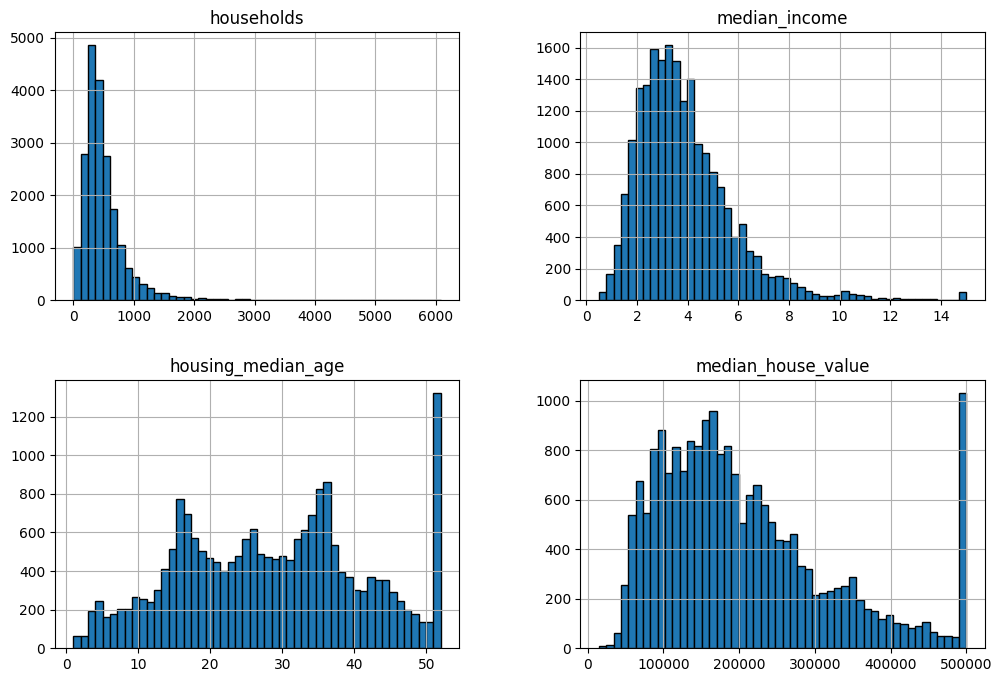

In [144]:
print("5. Create a histogram for the following columns: “households”, “median_income”, “housing_median_age” and “median_house_value”.\n")
# https://www.geeksforgeeks.org/pandas/pandas-built-in-data-visualization-ml/
# https://www.geeksforgeeks.org/python/python-introduction-matplotlib/
# https://www.datacamp.com/tutorial/matplotlib-tutorial-python

kolumner = ["households", "median_income", "housing_median_age", "median_house_value"]
data[kolumner].hist(bins=50, figsize=(12, 8), edgecolor='black')

plt.show()


In [145]:
print("6. What can you highlight in these graphs?")
print("Specifically focus on end of the “housing_median_age” and “median_house_value” graphs.")
print("What do you think about the magnitude of the values in “median_house_value”?\n")

print("housing_median_age:\nThe area started to be populated more than 50 years ago. Most likely, the last category is '50 years or older',\ncollecting all older housings in one column. Since then we can see small booms aproximately every ten years; 35, 25 and 15 years ago.\n")

print("median_house_value:\nThe majority of the housings are valued from 75k to 250k. Then we can see a decrease in values\nand similar to housing_median_age, the last category is likely 'Worth 500k or more'.\n")

6. What can you highlight in these graphs?
Specifically focus on end of the “housing_median_age” and “median_house_value” graphs.
What do you think about the magnitude of the values in “median_house_value”?

housing_median_age:
The area started to be populated more than 50 years ago. Most likely, the last category is '50 years or older',
collecting all older housings in one column. Since then we can see small booms aproximately every ten years; 35, 25 and 15 years ago.

median_house_value:
The majority of the housings are valued from 75k to 250k. Then we can see a decrease in values
and similar to housing_median_age, the last category is likely 'Worth 500k or more'.



In [146]:
print("7. In which category are the most expensive and the largest houses typically located? In which category are the least expensive and smallest houses typically located?\n")
# https://www.geeksforgeeks.org/pandas/pandas-groupby/

data['rooms_per_household'] = (data['total_rooms'] + data['total_bedrooms']) / data['households']

grp = data.groupby('ocean_proximity')[['median_house_value', 'rooms_per_household']].mean().sort_values(by='median_house_value', ascending=False)

print(grp.round(2),"\n")

print("The most expensive housing are located on the islands, and the least expensive ones are located inland.\nInterestingly enough, the largest houses (defined by bumber of rooms) are\nlocated in the inland and on the islands.")

7. In which category are the most expensive and the largest houses typically located? In which category are the least expensive and smallest houses typically located?

                 median_house_value  rooms_per_household
ocean_proximity                                         
ISLAND                    380440.00                 7.18
NEAR BAY                  259212.31                 6.28
NEAR OCEAN                249433.98                 6.28
<1H OCEAN                 240084.29                 6.20
INLAND                    124805.39                 7.17 

The most expensive housing are located on the islands, and the least expensive ones are located inland.
Interestingly enough, the largest houses (defined by bumber of rooms) are
located in the inland and on the islands.


In [147]:
print("8. What can you tell about the quality of houses in each “Ocean_proximity” category? (e.g., the age of the houses, the number of rooms)\n")

data['rooms_per_household'] = (data['total_rooms'] + data['total_bedrooms']) / data['households']
data['value_per_room'] = data['median_house_value'] / data['rooms_per_household']

grp = data.groupby('ocean_proximity')[['housing_median_age', 'median_house_value', 'rooms_per_household', 'value_per_room']].mean().sort_values(by='median_house_value', ascending=False)

print(grp.round(2),"\n")

print("The housing on the islands are oldest, largest (with regards to number of rooms), and most expensive. This could be seen as an indicator for top quality.")
print("On the other end of the spectrum, the inland housing is the youngest, cheapest and at the same time also largest. This can be, but isn't necessarily, an indicator for lower quality.\n")
print("I'm not sure what the difference between near bay and near ocean is, but I will assume that near bay is closer to the ocean than near ocean.\n")
print("If you're not living in direct proximity to the ocean, it doesn't really make a difference for the housing up to an hours distance from the ocean.")
print("Housing near ocean and <1H from ocean are similar in size, age and value.\n")
print("Housing near bay is similar in value and size to near and <1H ocean. They are however almost 10 years older.\n")
print("Quality is a subjective measurement. Do you value the exclusivity of island life or a larger but cheaper home away from the water?")

8. What can you tell about the quality of houses in each “Ocean_proximity” category? (e.g., the age of the houses, the number of rooms)

                 housing_median_age  median_house_value  rooms_per_household  value_per_room
ocean_proximity                                                                             
ISLAND                        42.40           380440.00                 7.18        54355.99
NEAR BAY                      37.73           259212.31                 6.28        41814.55
NEAR OCEAN                    29.35           249433.98                 6.28        39545.14
<1H OCEAN                     29.28           240084.29                 6.20        38958.17
INLAND                        24.27           124805.39                 7.17        18258.95 

The housing on the islands are oldest, largest (with regards to number of rooms), and most expensive. This could be seen as an indicator for top quality.
On the other end of the spectrum, the inland housing is 

In [148]:
# 9. What can you tell about the demographic living in each “Ocean_proximity” category? (e.g., population, households, median income)
# https://www.geeksforgeeks.org/python/grouping-and-aggregating-with-pandas/

# Working on this question, I realised that mean of means gave misleading results.

demographics = data.groupby('ocean_proximity').agg({
    'median_house_value' : 'mean',
    'population' : 'sum',
    'households' : 'sum',
    'median_income' : 'mean'    
})

demographics['median_income'] = demographics['median_income'] * 10000

demographics['people_per_household'] = demographics['population'] / demographics['households']
demographics['income_per_household'] = demographics['median_income'] / demographics['people_per_household']

print(demographics.sort_values(by='median_house_value', ascending=False).round(2),"\n")

print("Assuming that each household consists of parents and kids, we can see that the households gets bigger the further from the ocean you live. The biggest families lives <1H from the ocean.\n")
print("People in the inland value space and more economic freedom instead of putting more money into housing.\n")
print("Near bay is interesting. We see the largest income per household, and at the same time less kids. DINKIES?\n")
print("Island came as a surprise. Second lowest income of all areas combined with lowest amount of kids. Retired people with old money, perhaps?")


                 median_house_value  population  households  median_income  people_per_household  income_per_household
ocean_proximity                                                                                                       
ISLAND                    380440.00      3340.0      1383.0       27444.20                  2.42              11363.87
NEAR BAY                  259212.31   2817427.0   1118931.0       41728.85                  2.52              16572.46
NEAR OCEAN                249433.98   3598955.0   1332308.0       40057.85                  2.70              14829.14
<1H OCEAN                 240084.29  13889374.0   4730118.0       42306.82                  2.94              14407.87
INLAND                    124805.39   9112744.0   3127759.0       32089.96                  2.91              11014.21 

Assuming that each household consists of parents and kids, we can see that the households gets bigger the further from the ocean you live. The biggest families lives

In [149]:
# 10. Are there any other interesting observations and questions you can come up with regarding this dataset?

